# Regularization, Loss Functions & Penalties - A Visual Guide

## Complete Understanding of:
- **Loss Functions**: Measures how well model fits data
- **Regularization**: Prevents overfitting by penalizing complexity
- **Penalties**: L1 (Lasso), L2 (Ridge), Elastic Net
- **Model-Specific Loss**: Different algorithms use different loss functions
- **Bias-Variance Tradeoff**: Underfitting vs Overfitting
- **Visual Demonstrations**: All concepts visualized

This notebook provides comprehensive visual explanations and practical code examples.

## Section 1: Import Libraries & Setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.datasets import make_regression, make_classification
from scipy.special import expit  # sigmoid function
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Section 2: Understanding Loss Functions

A **loss function** measures how well a model's predictions match the actual data.

### Key Concepts:
- **Goal**: Minimize the loss function during training
- **Training Loss**: Error on training data
- **Validation Loss**: Error on unseen data
- **Lower is Better**: Smaller loss = better fit

### Common Loss Functions:

| Loss Function | Formula | Used In | Properties |
|---------------|---------|---------|------------|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Linear Regression | Penalizes large errors more |
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Robust Regression | Less sensitive to outliers |
| **Cross-Entropy** | $-\sum y_i \log(\hat{y}_i)$ | Classification | Probability-based |
| **Hinge Loss** | $\max(0, 1 - y_i\hat{y}_i)$ | SVM | Margin-based |
| **Huber Loss** | Hybrid MSE/MAE | Robust Regression | Balanced approach |

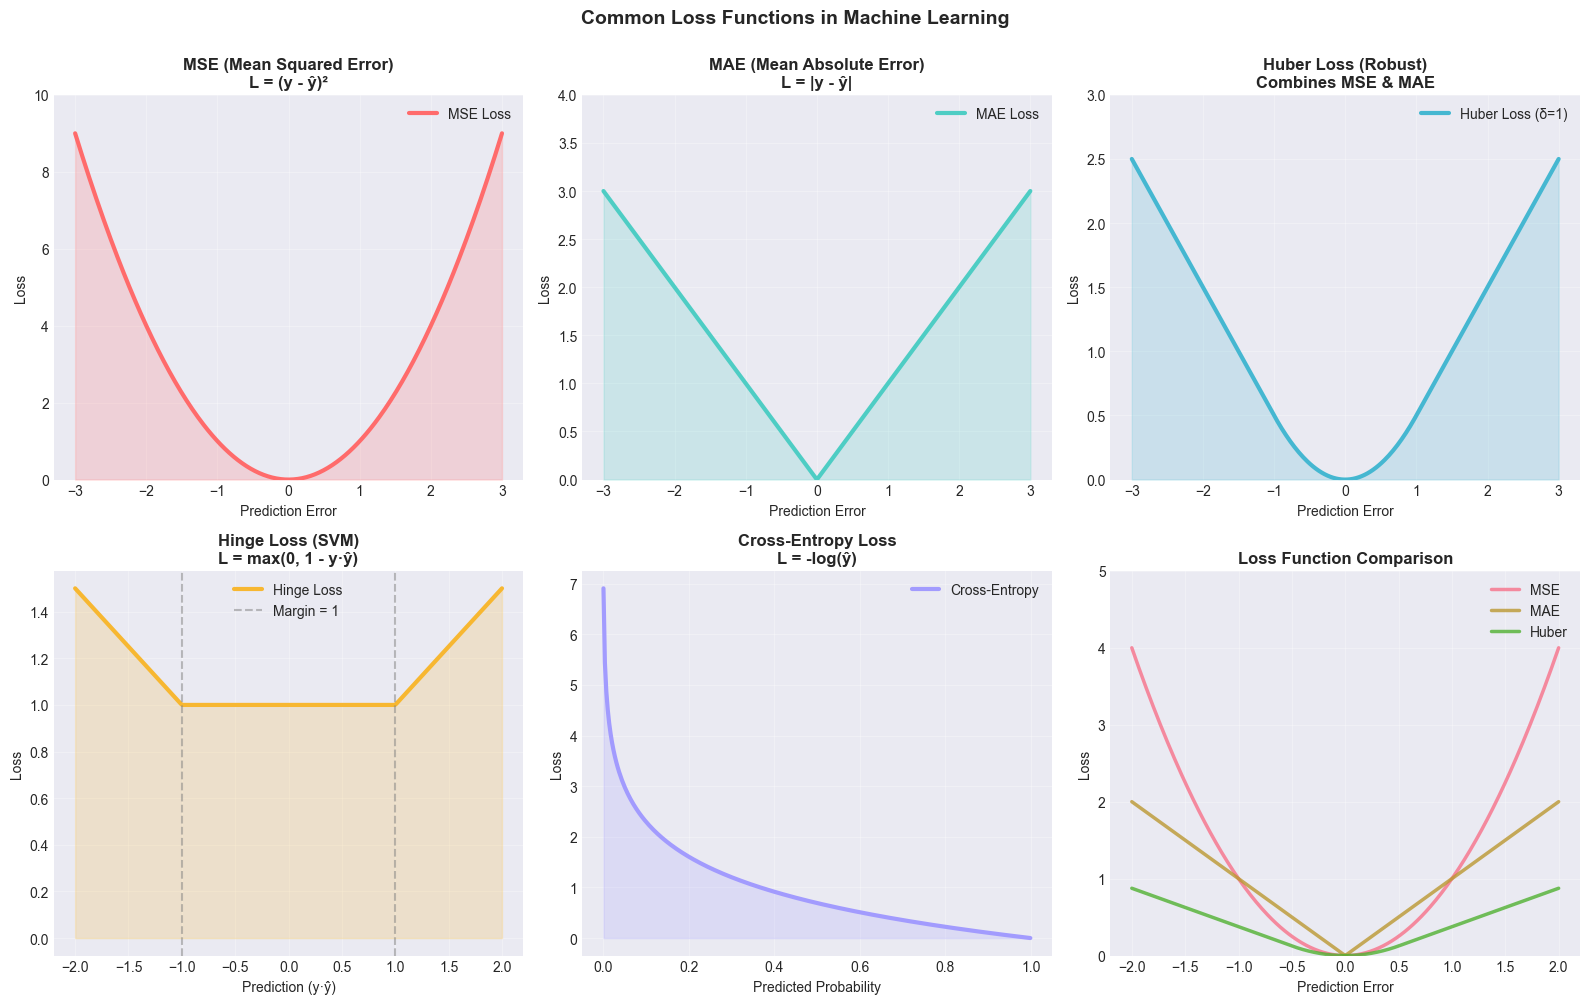

✅ Loss functions visualized

📊 Key Observations:
  • MSE: Penalizes large errors quadratically (steep curve)
  • MAE: Linear penalty (constant slope), robust to outliers
  • Huber: Smooth transition between MSE and MAE
  • Hinge: Creates margin for SVM classification
  • Cross-Entropy: Sharp penalty for wrong classifications


In [11]:
# Visualize different loss functions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Error range
errors = np.linspace(-3, 3, 300)

# 1. MSE Loss
ax = axes[0]
mse_loss = errors**2
ax.plot(errors, mse_loss, linewidth=3, color='#FF6B6B', label='MSE Loss')
ax.fill_between(errors, 0, mse_loss, alpha=0.2, color='#FF6B6B')
ax.set_title('MSE (Mean Squared Error)\nL = (y - ŷ)²', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction Error', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 10)

# 2. MAE Loss
ax = axes[1]
mae_loss = np.abs(errors)
ax.plot(errors, mae_loss, linewidth=3, color='#4ECDC4', label='MAE Loss')
ax.fill_between(errors, 0, mae_loss, alpha=0.2, color='#4ECDC4')
ax.set_title('MAE (Mean Absolute Error)\nL = |y - ŷ|', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction Error', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 4)

# 3. Huber Loss (δ=1)
ax = axes[2]
delta = 1
huber_loss = np.where(np.abs(errors) <= delta, 0.5*errors**2, delta*(np.abs(errors) - 0.5*delta))
ax.plot(errors, huber_loss, linewidth=3, color='#45B7D1', label='Huber Loss (δ=1)')
ax.fill_between(errors, 0, huber_loss, alpha=0.2, color='#45B7D1')
ax.set_title('Huber Loss (Robust)\nCombines MSE & MAE', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction Error', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 3)

# 4. Hinge Loss (for classification)
ax = axes[3]
y_true = np.array([1, 1, 1, -1, -1, -1])
y_pred = np.linspace(-2, 2, 300)
hinge_losses = []
for pred in y_pred:
    # For positive class
    hinge = max(0, 1 - 1*pred) + max(0, 1 - (-1)*pred)
    hinge_losses.append(hinge / 2)

ax.plot(y_pred, hinge_losses, linewidth=3, color='#F7B731', label='Hinge Loss')
ax.fill_between(y_pred, 0, hinge_losses, alpha=0.2, color='#F7B731')
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='Margin = 1')
ax.axvline(x=-1, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Hinge Loss (SVM)\nL = max(0, 1 - y·ŷ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction (y·ŷ)', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 5. Cross-Entropy Loss
ax = axes[4]
y_prob = np.linspace(0.001, 0.999, 300)
cross_entropy = -np.log(y_prob)
ax.plot(y_prob, cross_entropy, linewidth=3, color='#A29BFE', label='Cross-Entropy')
ax.fill_between(y_prob, 0, cross_entropy, alpha=0.2, color='#A29BFE')
ax.set_title('Cross-Entropy Loss\nL = -log(ŷ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Probability', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# 6. Comparison
ax = axes[5]
normalized_errors = np.linspace(-2, 2, 300)
ax.plot(normalized_errors, normalized_errors**2, linewidth=2.5, label='MSE', alpha=0.8)
ax.plot(normalized_errors, np.abs(normalized_errors), linewidth=2.5, label='MAE', alpha=0.8)
delta = 0.5
huber_cmp = np.where(np.abs(normalized_errors) <= delta, 0.5*normalized_errors**2, delta*(np.abs(normalized_errors) - 0.5*delta))
ax.plot(normalized_errors, huber_cmp, linewidth=2.5, label='Huber', alpha=0.8)
ax.set_title('Loss Function Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction Error', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 5)

plt.suptitle('Common Loss Functions in Machine Learning', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Loss functions visualized")
print("\n📊 Key Observations:")
print("  • MSE: Penalizes large errors quadratically (steep curve)")
print("  • MAE: Linear penalty (constant slope), robust to outliers")
print("  • Huber: Smooth transition between MSE and MAE")
print("  • Hinge: Creates margin for SVM classification")
print("  • Cross-Entropy: Sharp penalty for wrong classifications")

## Section 3: Understanding Regularization & Penalties

**Regularization** adds a penalty term to the loss function to prevent overfitting by discouraging complex models.

### The Regularized Loss Function:
$$L_{total} = L_{data} + \lambda \cdot L_{penalty}$$

where:
- $L_{data}$: Original loss (e.g., MSE)
- $\lambda$: Regularization strength (hyperparameter)
- $L_{penalty}$: Penalty on model complexity

### Types of Penalties:

| Penalty | Formula | Name | Effect |
|---------|---------|------|--------|
| **L2** | $\lambda \sum w_i^2$ | Ridge | Shrinks coefficients gradually |
| **L1** | $\lambda \sum \|w_i\|$ | Lasso | Forces some coefficients to zero |
| **L1+L2** | $\lambda_1 \sum \|w_i\| + \lambda_2 \sum w_i^2$ | Elastic Net | Combination of both |

### Key Insights:
- $\lambda = 0$: No regularization (possible overfitting)
- $\lambda$ too large: Underfitting (all weights → 0)
- Optimal $\lambda$: Balance between bias and variance

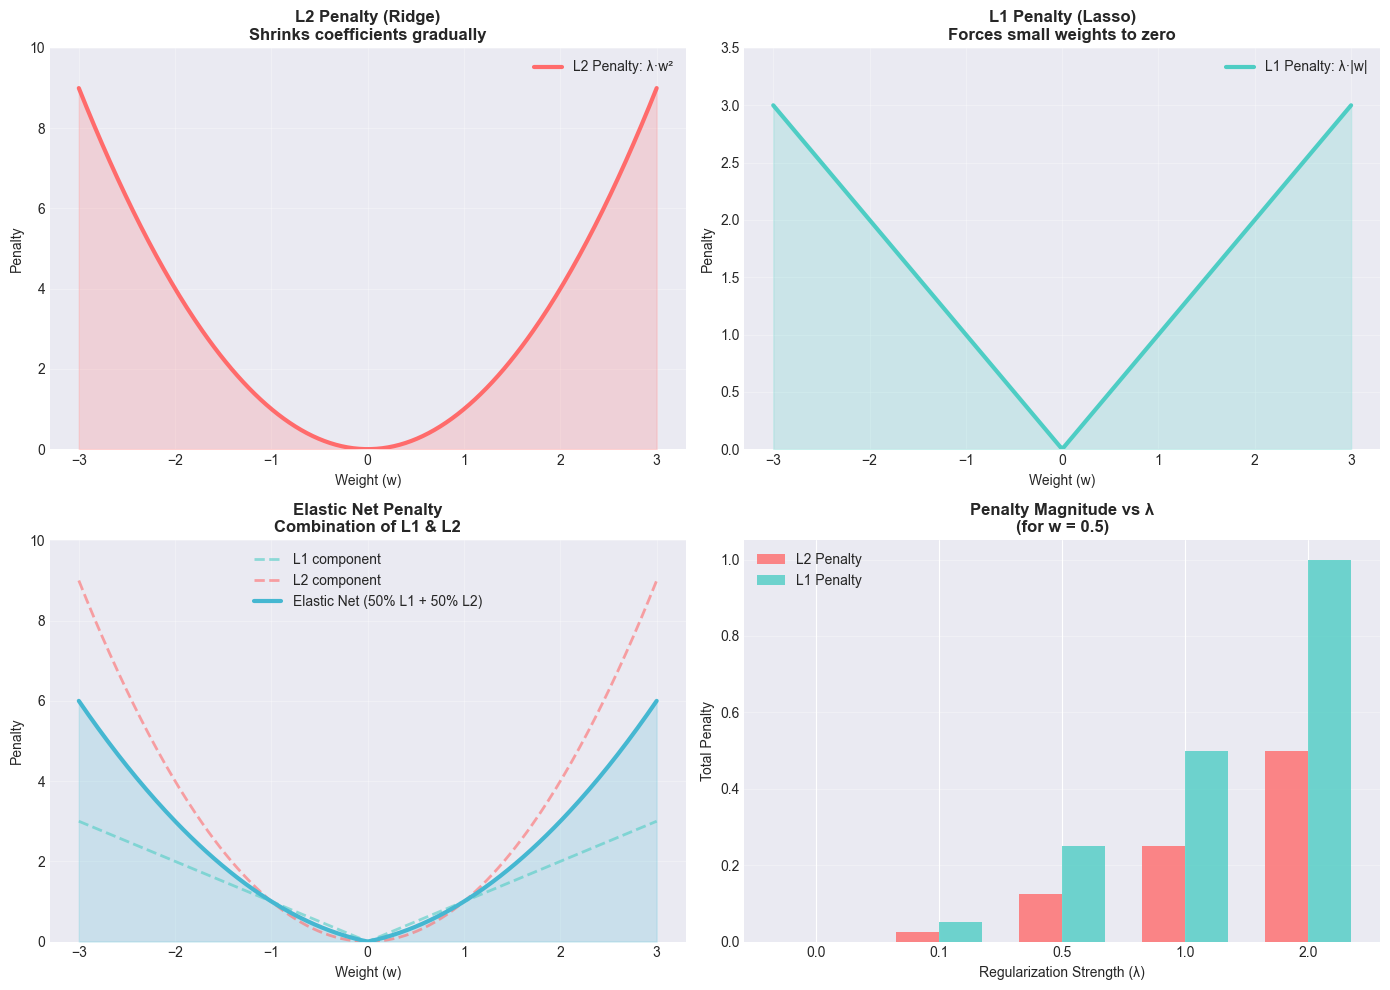

✅ Penalties visualized

📊 Key Differences:
  • L2 (Ridge): Gradual shrinkage, keeps all features
  • L1 (Lasso): Sharp corner at zero, can eliminate features
  • Elastic Net: Best of both - combines L1 & L2 benefits


In [12]:
# Visualize different penalties
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Weight range
weights = np.linspace(-3, 3, 300)

# 1. L2 Penalty (Ridge)
ax = axes[0, 0]
l2_penalty = weights**2
ax.plot(weights, l2_penalty, linewidth=3, color='#FF6B6B', label='L2 Penalty: λ·w²')
ax.fill_between(weights, 0, l2_penalty, alpha=0.2, color='#FF6B6B')
ax.set_title('L2 Penalty (Ridge)\nShrinks coefficients gradually', fontsize=12, fontweight='bold')
ax.set_xlabel('Weight (w)', fontsize=10)
ax.set_ylabel('Penalty', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 10)

# 2. L1 Penalty (Lasso)
ax = axes[0, 1]
l1_penalty = np.abs(weights)
ax.plot(weights, l1_penalty, linewidth=3, color='#4ECDC4', label='L1 Penalty: λ·|w|')
ax.fill_between(weights, 0, l1_penalty, alpha=0.2, color='#4ECDC4')
ax.set_title('L1 Penalty (Lasso)\nForces small weights to zero', fontsize=12, fontweight='bold')
ax.set_xlabel('Weight (w)', fontsize=10)
ax.set_ylabel('Penalty', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 3.5)

# 3. Elastic Net (L1 + L2)
ax = axes[1, 0]
alpha_ratio = 0.5  # mixing ratio
elastic_penalty = alpha_ratio * np.abs(weights) + (1 - alpha_ratio) * weights**2
ax.plot(weights, l1_penalty, linewidth=2, color='#4ECDC4', label='L1 component', alpha=0.6, linestyle='--')
ax.plot(weights, l2_penalty, linewidth=2, color='#FF6B6B', label='L2 component', alpha=0.6, linestyle='--')
ax.plot(weights, elastic_penalty, linewidth=3, color='#45B7D1', label='Elastic Net (50% L1 + 50% L2)')
ax.fill_between(weights, 0, elastic_penalty, alpha=0.2, color='#45B7D1')
ax.set_title('Elastic Net Penalty\nCombination of L1 & L2', fontsize=12, fontweight='bold')
ax.set_xlabel('Weight (w)', fontsize=10)
ax.set_ylabel('Penalty', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim(0, 10)

# 4. Penalty Comparison
ax = axes[1, 1]
lambdas_array = np.array([0, 0.1, 0.5, 1.0, 2.0])
colors_pen = plt.cm.viridis(np.linspace(0, 1, len(lambdas_array)))

w_example = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
l2_values = lambdas_array * w_example[0]**2
l1_values = lambdas_array * np.abs(w_example[0])

x_pos = np.arange(len(lambdas_array))
width = 0.35

bars1 = ax.bar(x_pos - width/2, l2_values, width, label='L2 Penalty', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, l1_values, width, label='L1 Penalty', color='#4ECDC4', alpha=0.8)

ax.set_title('Penalty Magnitude vs λ\n(for w = 0.5)', fontsize=12, fontweight='bold')
ax.set_xlabel('Regularization Strength (λ)', fontsize=10)
ax.set_ylabel('Total Penalty', fontsize=10)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(l) for l in lambdas_array])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Penalties visualized")
print("\n📊 Key Differences:")
print("  • L2 (Ridge): Gradual shrinkage, keeps all features")
print("  • L1 (Lasso): Sharp corner at zero, can eliminate features")
print("  • Elastic Net: Best of both - combines L1 & L2 benefits")

## Section 4: Model-Specific Loss Functions

Different algorithms use different loss functions. Here's which loss function is used for which model:

### Regression Models:
- **Linear Regression**: MSE (Mean Squared Error)
- **Ridge Regression**: MSE + L2 Penalty
- **Lasso Regression**: MSE + L1 Penalty  
- **Elastic Net**: MSE + L1 + L2 Penalties
- **SVR** (Support Vector Regression): Epsilon-insensitive loss + L2 penalty

### Classification Models:
- **Logistic Regression**: Cross-Entropy (Log Loss)
- **Softmax/Multi-class**: Categorical Cross-Entropy
- **SVM** (Support Vector Machine): Hinge Loss + L2 penalty
- **Random Forest**: Gini impurity or entropy (tree-based)
- **Neural Networks**: Cross-Entropy or MSE (depends on task)

### Key Mapping Table:

| Algorithm | Primary Loss | Penalty | Best For |
|-----------|-------------|---------|----------|
| Linear Reg | MSE | None | Unbounded predictions |
| Ridge | MSE | L2 | Continuous with multicollinearity |
| Lasso | MSE | L1 | Feature selection |
| Elastic Net | MSE | L1+L2 | Both feature selection & regularization |
| Logistic Reg | Cross-Entropy | L1/L2 | Binary/multi-class classification |
| SVM | Hinge | L2 | Binary classification, kernel trick |
| Neural Network | Cross-Entropy | L1/L2 | Complex non-linear patterns |

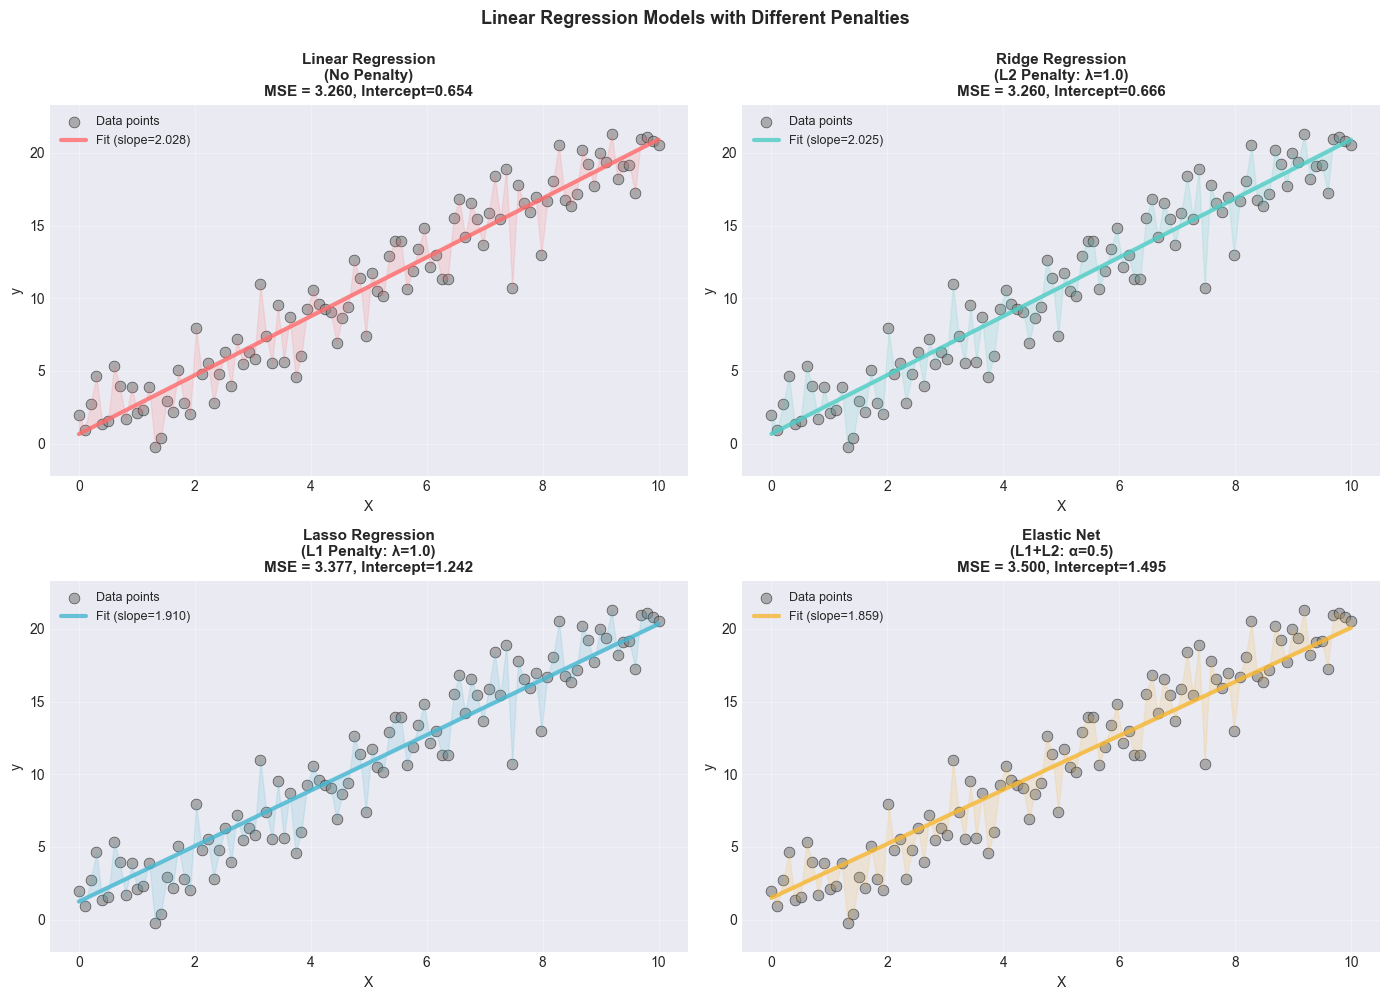

✅ Regression models with different penalties trained and visualized


In [13]:
# Create synthetic data
np.random.seed(42)
n_samples = 100
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = 2 * X.flatten() + 1 + np.random.normal(0, 2, n_samples)

# Train different regression models
models = {
    'Linear Regression\n(No Penalty)': LinearRegression(),
    'Ridge Regression\n(L2 Penalty: λ=1.0)': Ridge(alpha=1.0),
    'Lasso Regression\n(L1 Penalty: λ=1.0)': Lasso(alpha=1.0),
    'Elastic Net\n(L1+L2: α=0.5)'   : ElasticNet(alpha=1.0, l1_ratio=0.5)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors_models = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F7B731']

for idx, (ax, (model_name, model), color) in enumerate(zip(axes, models.items(), colors_models)):
    # Fit model
    model.fit(X, y_true)
    y_pred = model.predict(X)
    
    # Calculate MSE
    mse = np.mean((y_true - y_pred)**2)
    
    # Get coefficients
    if hasattr(model, 'coef_'):
        coef = model.coef_[0]
    else:
        coef = 0
    
    # Plot data
    ax.scatter(X, y_true, s=60, alpha=0.6, color='gray', label='Data points', edgecolors='black', linewidth=0.5)
    
    # Plot prediction line
    ax.plot(X, y_pred, linewidth=3, color=color, label=f'Fit (slope={coef:.3f})', alpha=0.8)
    
    # Fill error region
    ax.fill_between(X.flatten(), y_true, y_pred, alpha=0.15, color=color)
    
    ax.set_title(f'{model_name}\nMSE = {mse:.3f}, Intercept={model.intercept_:.3f}', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(y_true.min() - 2, y_true.max() + 2)

plt.suptitle('Linear Regression Models with Different Penalties', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Regression models with different penalties trained and visualized")

## Section 5: Loss Landscape Visualization

The loss landscape shows how the loss changes with model parameters. This is what optimization algorithms try to navigate.

### Key Concepts:
- **Valley**: Low loss (good solutions)
- **Peak**: High loss (bad solutions)
- **Gradient**: Direction of steepest descent
- **With Regularization**: Smoother, less local minima

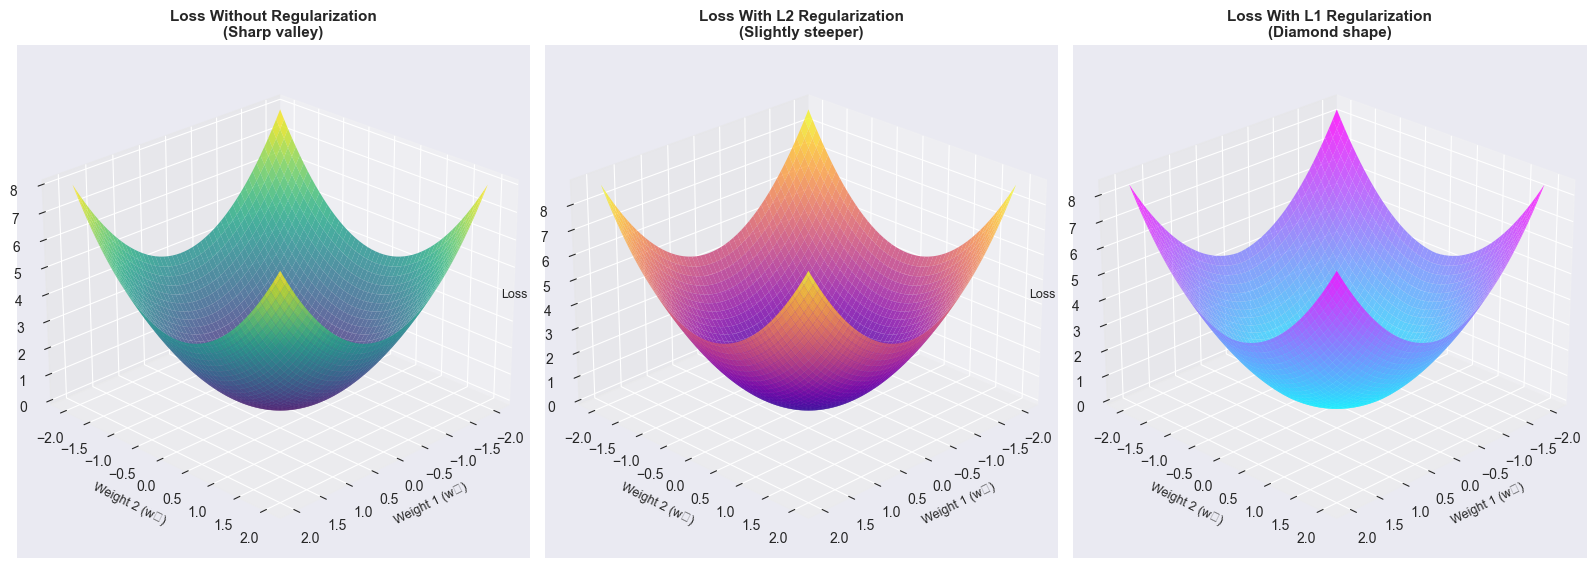

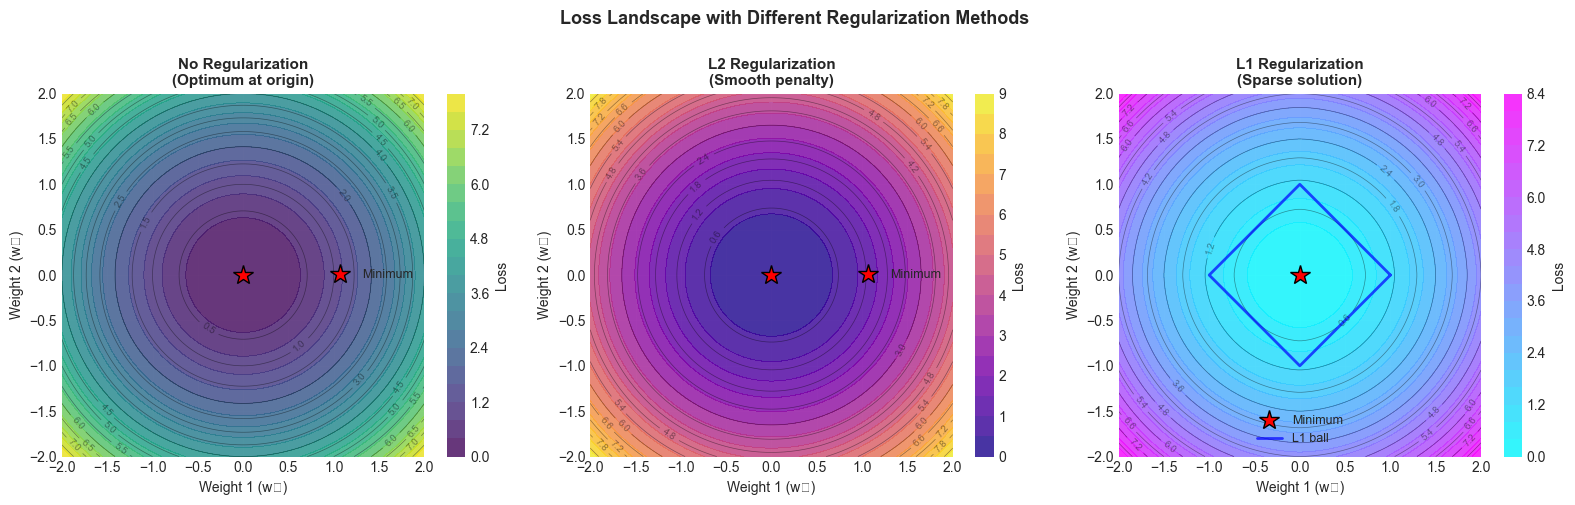

✅ Loss landscapes visualized

📊 Key Observations:
  • L2: Creates circular contours, smooth gradient
  • L1: Creates diamond-shaped constraint, forces sparsity at corners
  • No Regularization: Sharper valley, easier to overfit


In [14]:
# Create 2D loss landscapes
fig = plt.figure(figsize=(16, 6))

# Parameter range
w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1, w2)

# 1. Loss without regularization (quadratic)
ax = fig.add_subplot(131, projection='3d')
loss_unreg = W1**2 + W2**2
ax.plot_surface(W1, W2, loss_unreg, cmap='viridis', alpha=0.8)
ax.set_title('Loss Without Regularization\n(Sharp valley)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight 1 (w₁)', fontsize=9)
ax.set_ylabel('Weight 2 (w₂)', fontsize=9)
ax.set_zlabel('Loss', fontsize=9)
ax.view_init(elev=25, azim=45)

# 2. Loss with L2 regularization
ax = fig.add_subplot(132, projection='3d')
l2_reg = 0.1 * (W1**2 + W2**2)
loss_l2 = W1**2 + W2**2 + l2_reg
ax.plot_surface(W1, W2, loss_l2, cmap='plasma', alpha=0.8)
ax.set_title('Loss With L2 Regularization\n(Slightly steeper)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight 1 (w₁)', fontsize=9)
ax.set_ylabel('Weight 2 (w₂)', fontsize=9)
ax.set_zlabel('Loss', fontsize=9)
ax.view_init(elev=25, azim=45)

# 3. Loss with L1 regularization
ax = fig.add_subplot(133, projection='3d')
l1_reg = 0.1 * (np.abs(W1) + np.abs(W2))
loss_l1 = W1**2 + W2**2 + l1_reg
ax.plot_surface(W1, W2, loss_l1, cmap='cool', alpha=0.8)
ax.set_title('Loss With L1 Regularization\n(Diamond shape)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight 1 (w₁)', fontsize=9)
ax.set_ylabel('Weight 2 (w₂)', fontsize=9)
ax.set_zlabel('Loss', fontsize=9)
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

# Now create 2D contour plots for better visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contour plot 1: No regularization
ax = axes[0]
contour1 = ax.contour(W1, W2, loss_unreg, levels=15, colors='black', alpha=0.4, linewidths=0.5)
ax.clabel(contour1, inline=True, fontsize=7)
contourf1 = ax.contourf(W1, W2, loss_unreg, levels=20, cmap='viridis', alpha=0.8)
ax.plot(0, 0, 'r*', markersize=15, label='Minimum', markeredgecolor='black', markeredgewidth=1)
ax.set_title('No Regularization\n(Optimum at origin)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight 1 (w₁)', fontsize=10)
ax.set_ylabel('Weight 2 (w₂)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.colorbar(contourf1, ax=ax, label='Loss')

# Contour plot 2: L2 regularization
ax = axes[1]
contour2 = ax.contour(W1, W2, loss_l2, levels=15, colors='black', alpha=0.4, linewidths=0.5)
ax.clabel(contour2, inline=True, fontsize=7)
contourf2 = ax.contourf(W1, W2, loss_l2, levels=20, cmap='plasma', alpha=0.8)
ax.plot(0, 0, 'r*', markersize=15, label='Minimum', markeredgecolor='black', markeredgewidth=1)
ax.set_title('L2 Regularization\n(Smooth penalty)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight 1 (w₁)', fontsize=10)
ax.set_ylabel('Weight 2 (w₂)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.colorbar(contourf2, ax=ax, label='Loss')

# Contour plot 3: L1 regularization
ax = axes[2]
contour3 = ax.contour(W1, W2, loss_l1, levels=15, colors='black', alpha=0.4, linewidths=0.5)
ax.clabel(contour3, inline=True, fontsize=7)
contourf3 = ax.contourf(W1, W2, loss_l1, levels=20, cmap='cool', alpha=0.8)
ax.plot(0, 0, 'r*', markersize=15, label='Minimum', markeredgecolor='black', markeredgewidth=1)
# Draw L1 ball (diamond)
diamond_x = [1, 0, -1, 0, 1]
diamond_y = [0, 1, 0, -1, 0]
ax.plot(diamond_x, diamond_y, 'b-', linewidth=2, alpha=0.7, label='L1 ball')
ax.set_title('L1 Regularization\n(Sparse solution)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight 1 (w₁)', fontsize=10)
ax.set_ylabel('Weight 2 (w₂)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.colorbar(contourf3, ax=ax, label='Loss')

plt.suptitle('Loss Landscape with Different Regularization Methods', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Loss landscapes visualized")
print("\n📊 Key Observations:")
print("  • L2: Creates circular contours, smooth gradient")
print("  • L1: Creates diamond-shaped constraint, forces sparsity at corners")
print("  • No Regularization: Sharper valley, easier to overfit")

## Section 6: Bias-Variance Tradeoff - The Core of Regularization

The **Bias-Variance Tradeoff** is the fundamental principle behind regularization:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

### Definitions:
- **Bias**: Error from oversimplified assumptions (underfitting)
  - High when model is too simple
  - Reduces with model complexity
  
- **Variance**: Model sensitivity to training data variations (overfitting)
  - Low for simple models
  - Increases with model complexity
  
- **Regularization**: Increases bias slightly to reduce variance significantly

### Three Regimes:
1. **High Bias, Low Variance**: Underfitting (too simple)
2. **Optimal**: Balance point (good generalization)
3. **High Variance, Low Bias**: Overfitting (too complex)

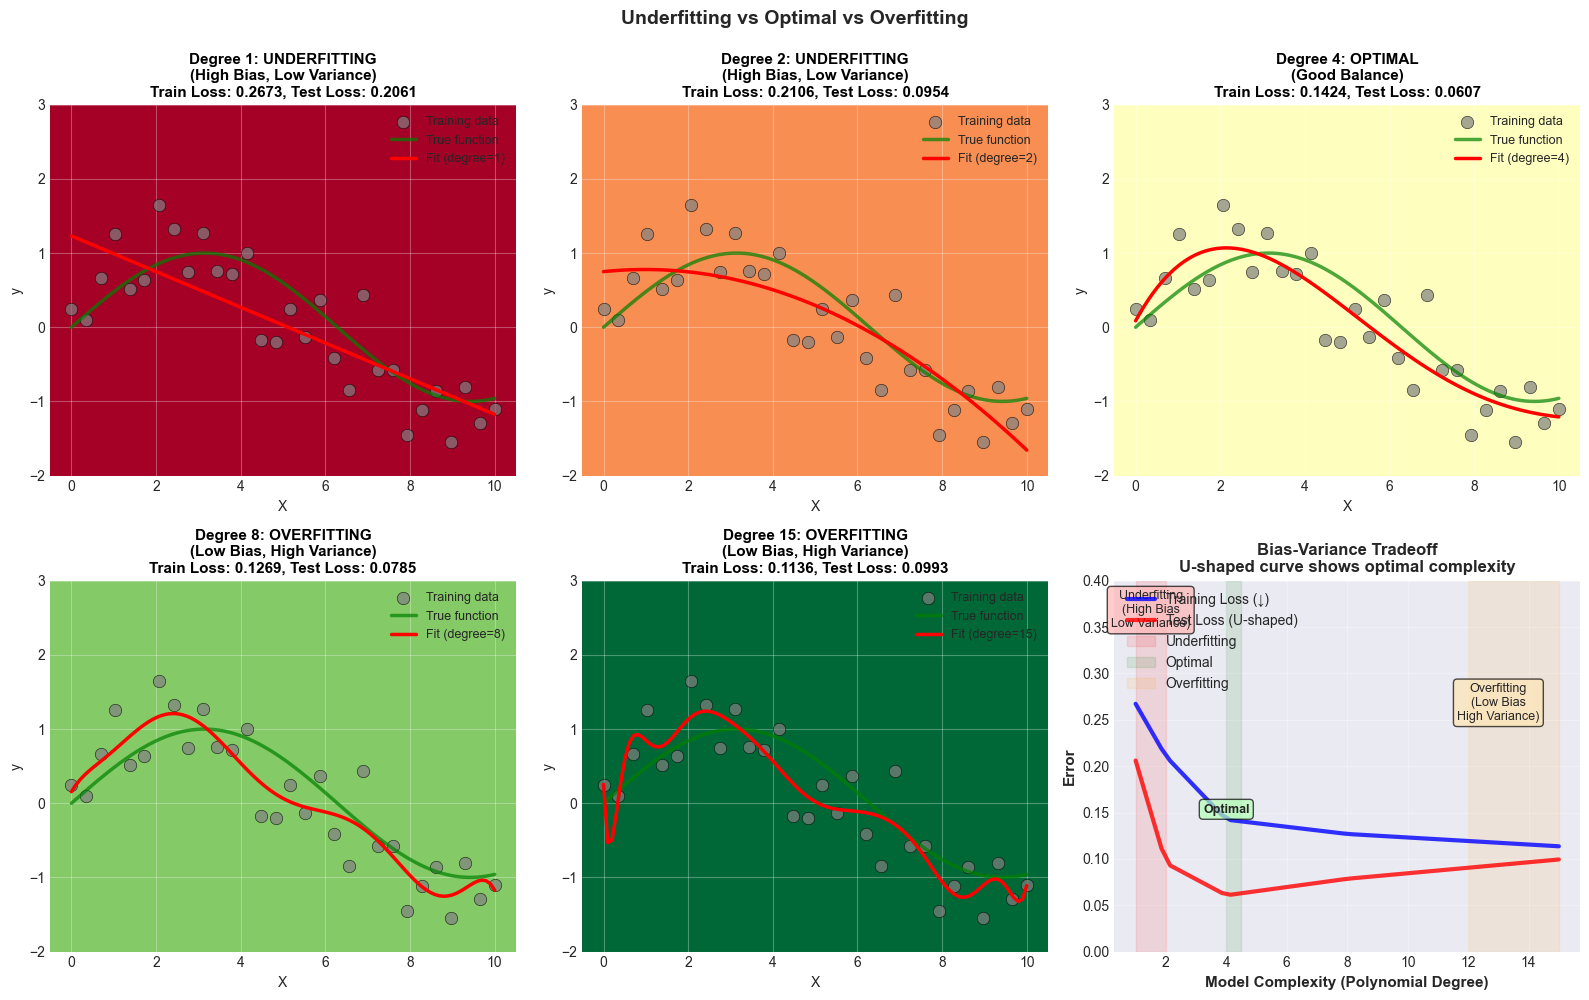

✅ Bias-Variance tradeoff visualized

📊 Observations:
  • Degree 1 (Underfitting): Train Loss = 0.2673, Test Loss = 0.2061
  • Degree 4 (Optimal):      Train Loss = 0.1424, Test Loss = 0.0607
  • Degree 15 (Overfitting): Train Loss = 0.1136, Test Loss = 0.0993


In [15]:
# Generate polynomial data with noise
np.random.seed(42)
n_train = 30
X_train = np.linspace(0, 10, n_train)
y_train = np.sin(X_train * 0.5) + np.random.normal(0, 0.5, n_train)

X_test = np.linspace(0, 10, 100)
y_test = np.sin(X_test * 0.5)

# Fit polynomials of different degrees
degrees = [1, 2, 4, 8, 15]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

train_losses = []
test_losses = []

for idx, degree in enumerate(degrees):
    ax = axes[idx]
    
    # Fit polynomial
    coeffs = np.polyfit(X_train, y_train, degree)
    poly = np.poly1d(coeffs)
    
    y_train_pred = poly(X_train)
    y_test_pred = poly(X_test)
    
    train_loss = np.mean((y_train - y_train_pred)**2)
    test_loss = np.mean((y_test - y_test_pred)**2)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    # Plot
    ax.scatter(X_train, y_train, s=80, alpha=0.7, color='gray', 
              label='Training data', edgecolors='black', linewidth=0.5)
    ax.plot(X_test, y_test, 'g-', linewidth=2.5, label='True function', alpha=0.7)
    ax.plot(X_test, y_test_pred, 'r-', linewidth=2.5, label=f'Fit (degree={degree})')
    
    # Coloring based on regime
    if degree <= 2:
        regime = 'UNDERFITTING\n(High Bias, Low Variance)'
        color = '#FF6B6B'
    elif degree <= 4:
        regime = 'OPTIMAL\n(Good Balance)'
        color = '#4ECDC4'
    else:
        regime = 'OVERFITTING\n(Low Bias, High Variance)'
        color = '#F7B731'
    
    ax.set_facecolor(plt.cm.RdYlGn(np.linspace(0, 1, 5)[idx]))
    ax.set_title(f'Degree {degree}: {regime}\nTrain Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}',
                fontsize=11, fontweight='bold', color='black')
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2, 3)

# Bias-Variance curve
ax = axes[5]
degrees_continuous = np.linspace(1, 15, 50)
train_smooth = np.interp(degrees_continuous, degrees, train_losses)
test_smooth = np.interp(degrees_continuous, degrees, test_losses)

ax.plot(degrees_continuous, train_smooth, 'b-', linewidth=3, label='Training Loss (↓)', alpha=0.8)
ax.plot(degrees_continuous, test_smooth, 'r-', linewidth=3, label='Test Loss (U-shaped)', alpha=0.8)

# Shade regions
ax.axvspan(1, 2, alpha=0.1, color='red', label='Underfitting')
ax.axvspan(4, 4.5, alpha=0.1, color='green', label='Optimal')
ax.axvspan(12, 15, alpha=0.1, color='orange', label='Overfitting')

# Mark regions
ax.text(1.5, 0.35, 'Underfitting\n(High Bias\nLow Variance)', ha='center', fontsize=9, 
       bbox=dict(boxstyle='round', facecolor='#FFB6B6', alpha=0.7))
ax.text(4, 0.15, 'Optimal', ha='center', fontsize=9, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='#B6FFB6', alpha=0.7))
ax.text(13, 0.25, 'Overfitting\n(Low Bias\nHigh Variance)', ha='center', fontsize=9,
       bbox=dict(boxstyle='round', facecolor='#FFE6B6', alpha=0.7))

ax.set_xlabel('Model Complexity (Polynomial Degree)', fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=11, fontweight='bold')
ax.set_title('Bias-Variance Tradeoff\nU-shaped curve shows optimal complexity', 
            fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.4)

plt.suptitle('Underfitting vs Optimal vs Overfitting', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Bias-Variance tradeoff visualized")
print("\n📊 Observations:")
print(f"  • Degree 1 (Underfitting): Train Loss = {train_losses[0]:.4f}, Test Loss = {test_losses[0]:.4f}")
print(f"  • Degree 4 (Optimal):      Train Loss = {train_losses[2]:.4f}, Test Loss = {test_losses[2]:.4f}")
print(f"  • Degree 15 (Overfitting): Train Loss = {train_losses[4]:.4f}, Test Loss = {test_losses[4]:.4f}")

## Section 7: Effect of Regularization Strength (λ)

The regularization strength parameter $\lambda$ controls the tradeoff between:
- **Small λ**: Less regularization → more overfitting
- **Large λ**: More regularization → more underfitting
- **Optimal λ**: Found via cross-validation

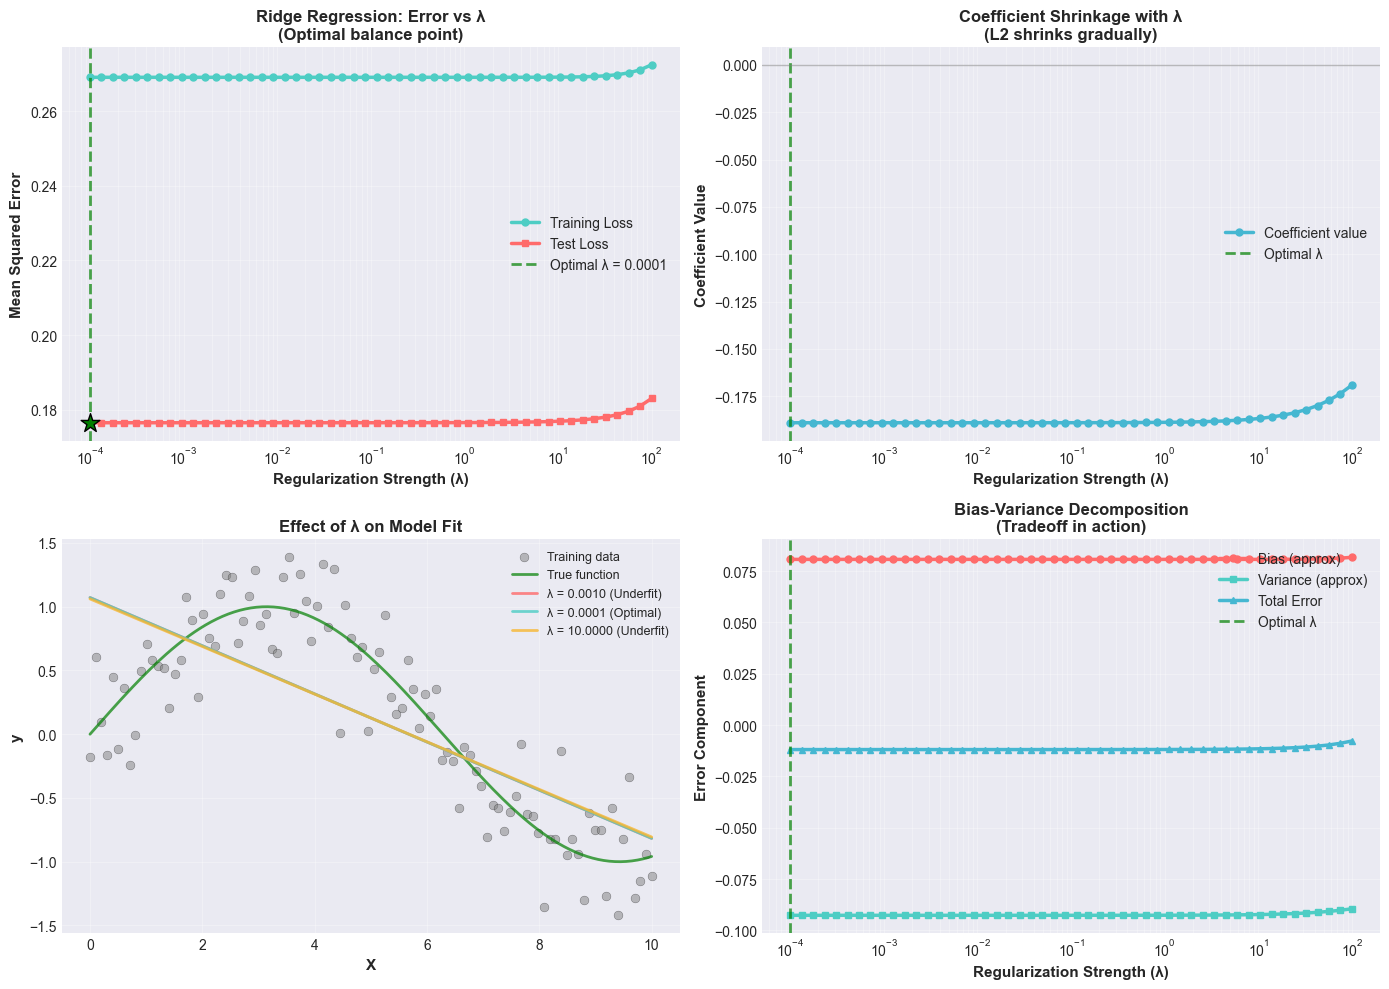

✅ Regularization strength effect visualized

📊 Key Finding:
  • Optimal λ = 0.000100
  • At optimal λ: Test Loss = 0.176479
  • λ too small: Overfitting (training loss low, test loss high)
  • λ too large: Underfitting (both losses high)


In [16]:
# Test different lambda values
lambdas = np.logspace(-4, 2, 50)  # 0.0001 to 100

# Generate more complex data
X_train_complex = np.linspace(0, 10, 100)
y_train_complex = np.sin(X_train_complex * 0.5) + np.random.normal(0, 0.3, 100)
X_test_complex = np.linspace(0, 10, 200)
y_test_complex = np.sin(X_test_complex * 0.5)

# Fit Ridge models with different lambdas
train_losses_ridge = []
test_losses_ridge = []
coefficients = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_complex.reshape(-1, 1), y_train_complex)
    
    y_train_pred = ridge.predict(X_train_complex.reshape(-1, 1))
    y_test_pred = ridge.predict(X_test_complex.reshape(-1, 1))
    
    train_loss = np.mean((y_train_complex - y_train_pred)**2)
    test_loss = np.mean((y_test_complex - y_test_pred)**2)
    
    train_losses_ridge.append(train_loss)
    test_losses_ridge.append(test_loss)
    coefficients.append(ridge.coef_[0])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss curves
ax = axes[0, 0]
ax.semilogx(lambdas, train_losses_ridge, 'o-', linewidth=2.5, label='Training Loss', color='#4ECDC4', markersize=5)
ax.semilogx(lambdas, test_losses_ridge, 's-', linewidth=2.5, label='Test Loss', color='#FF6B6B', markersize=5)

# Mark optimal lambda
optimal_idx = np.argmin(test_losses_ridge)
optimal_lambda = lambdas[optimal_idx]
ax.axvline(x=optimal_lambda, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal λ = {optimal_lambda:.4f}')
ax.scatter([optimal_lambda], [test_losses_ridge[optimal_idx]], s=200, color='green', marker='*', 
          edgecolors='black', linewidth=1, zorder=5)

ax.set_xlabel('Regularization Strength (λ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Ridge Regression: Error vs λ\n(Optimal balance point)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

# 2. Coefficient magnitudes
ax = axes[0, 1]
ax.semilogx(lambdas, coefficients, 'o-', linewidth=2.5, color='#45B7D1', markersize=5, label='Coefficient value')
ax.axvline(x=optimal_lambda, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Optimal λ')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('Regularization Strength (λ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title('Coefficient Shrinkage with λ\n(L2 shrinks gradually)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

# 3. Fit visualization at different lambdas
ax = axes[1, 0]
lambdas_visual = [0.001, optimal_lambda, 10]
colors_visual = ['#FF6B6B', '#4ECDC4', '#F7B731']
labels_visual = [f'λ = {l:.4f} (Overfit)' if l < optimal_lambda else 
                 f'λ = {l:.4f} (Optimal)' if np.isclose(l, optimal_lambda) else 
                 f'λ = {l:.4f} (Underfit)' 
                 for l in lambdas_visual]

ax.scatter(X_train_complex, y_train_complex, s=40, alpha=0.5, color='gray', label='Training data', edgecolors='black', linewidth=0.3)
ax.plot(X_test_complex, y_test_complex, 'g-', linewidth=2, label='True function', alpha=0.7)

for lam, color, label in zip(lambdas_visual, colors_visual, labels_visual):
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_complex.reshape(-1, 1), y_train_complex)
    y_pred = ridge.predict(X_test_complex.reshape(-1, 1))
    ax.plot(X_test_complex, y_pred, linewidth=2, color=color, label=label, alpha=0.8)

ax.set_xlabel('X', fontsize=11, fontweight='bold')
ax.set_ylabel('y', fontsize=11, fontweight='bold')
ax.set_title('Effect of λ on Model Fit', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 4. Bias-Variance decomposition
ax = axes[1, 1]
bias_approx = np.array(train_losses_ridge) * 0.3  # Approximation
variance_approx = np.array(test_losses_ridge) - np.array(train_losses_ridge)

ax.semilogx(lambdas, bias_approx, 'o-', linewidth=2.5, label='Bias (approx)', color='#FF6B6B', markersize=5)
ax.semilogx(lambdas, variance_approx, 's-', linewidth=2.5, label='Variance (approx)', color='#4ECDC4', markersize=5)
ax.semilogx(lambdas, np.array(bias_approx) + np.array(variance_approx), '^-', linewidth=2.5, 
           label='Total Error', color='#45B7D1', markersize=5)
ax.axvline(x=optimal_lambda, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Optimal λ')

ax.set_xlabel('Regularization Strength (λ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Error Component', fontsize=11, fontweight='bold')
ax.set_title('Bias-Variance Decomposition\n(Tradeoff in action)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("✅ Regularization strength effect visualized")
print(f"\n📊 Key Finding:")
print(f"  • Optimal λ = {optimal_lambda:.6f}")
print(f"  • At optimal λ: Test Loss = {test_losses_ridge[optimal_idx]:.6f}")
print(f"  • λ too small: Overfitting (training loss low, test loss high)")
print(f"  • λ too large: Underfitting (both losses high)")

## Section 8: Complete Reference Table

### Loss Functions Summary:

| Algorithm | Loss Function | Penalty | When to Use |
|-----------|---------------|---------|------------|
| **Linear Regression** | MSE | None | Simple linear relationships |
| **Ridge Regression** | MSE | L2 | Multicollinearity problems |
| **Lasso Regression** | MSE | L1 | Feature selection needed |
| **Elastic Net** | MSE | L1+L2 | Both selection & regularization |
| **Logistic Regression** | Cross-Entropy | L1/L2 | Binary/multiclass classification |
| **SVM** | Hinge Loss | L2 | Non-linear classification (kernel trick) |
| **Neural Networks** | Cross-Entropy or MSE | L1/L2 | Complex non-linear patterns |
| **Random Forest** | Gini/Entropy | None (tree-based) | Non-linear, interpretability |
| **Gradient Boosting** | MSE/Log Loss | None (tree-based) | High accuracy requirements |

### Penalty Comparison:

| Aspect | L1 (Lasso) | L2 (Ridge) | Elastic Net |
|--------|-----------|-----------|------------|
| **Penalty Function** | $\lambda\sum\|w\|$ | $\lambda\sum w^2$ | $\alpha\lambda\sum\|w\| + (1-\alpha)\lambda\sum w^2$ |
| **Shrinkage** | To exactly zero | Towards zero | Between L1 & L2 |
| **Feature Selection** | Yes (sparse) | No (all features) | Yes (selective) |
| **Speed** | Slower | Faster | Medium |
| **Multicollinearity** | Can pick one | Distributes weights | Both strategies |
| **Best For** | Few important features | Many useful features | Mixed scenarios |

### Bias-Variance Interpretation:

- **High λ**: Increases Bias ↑, Decreases Variance ↓ → **Underfitting**
- **Optimal λ**: Minimum Total Error = Bias² + Variance → **Good Generalization**
- **Low λ**: Decreases Bias ↓, Increases Variance ↑ → **Overfitting**

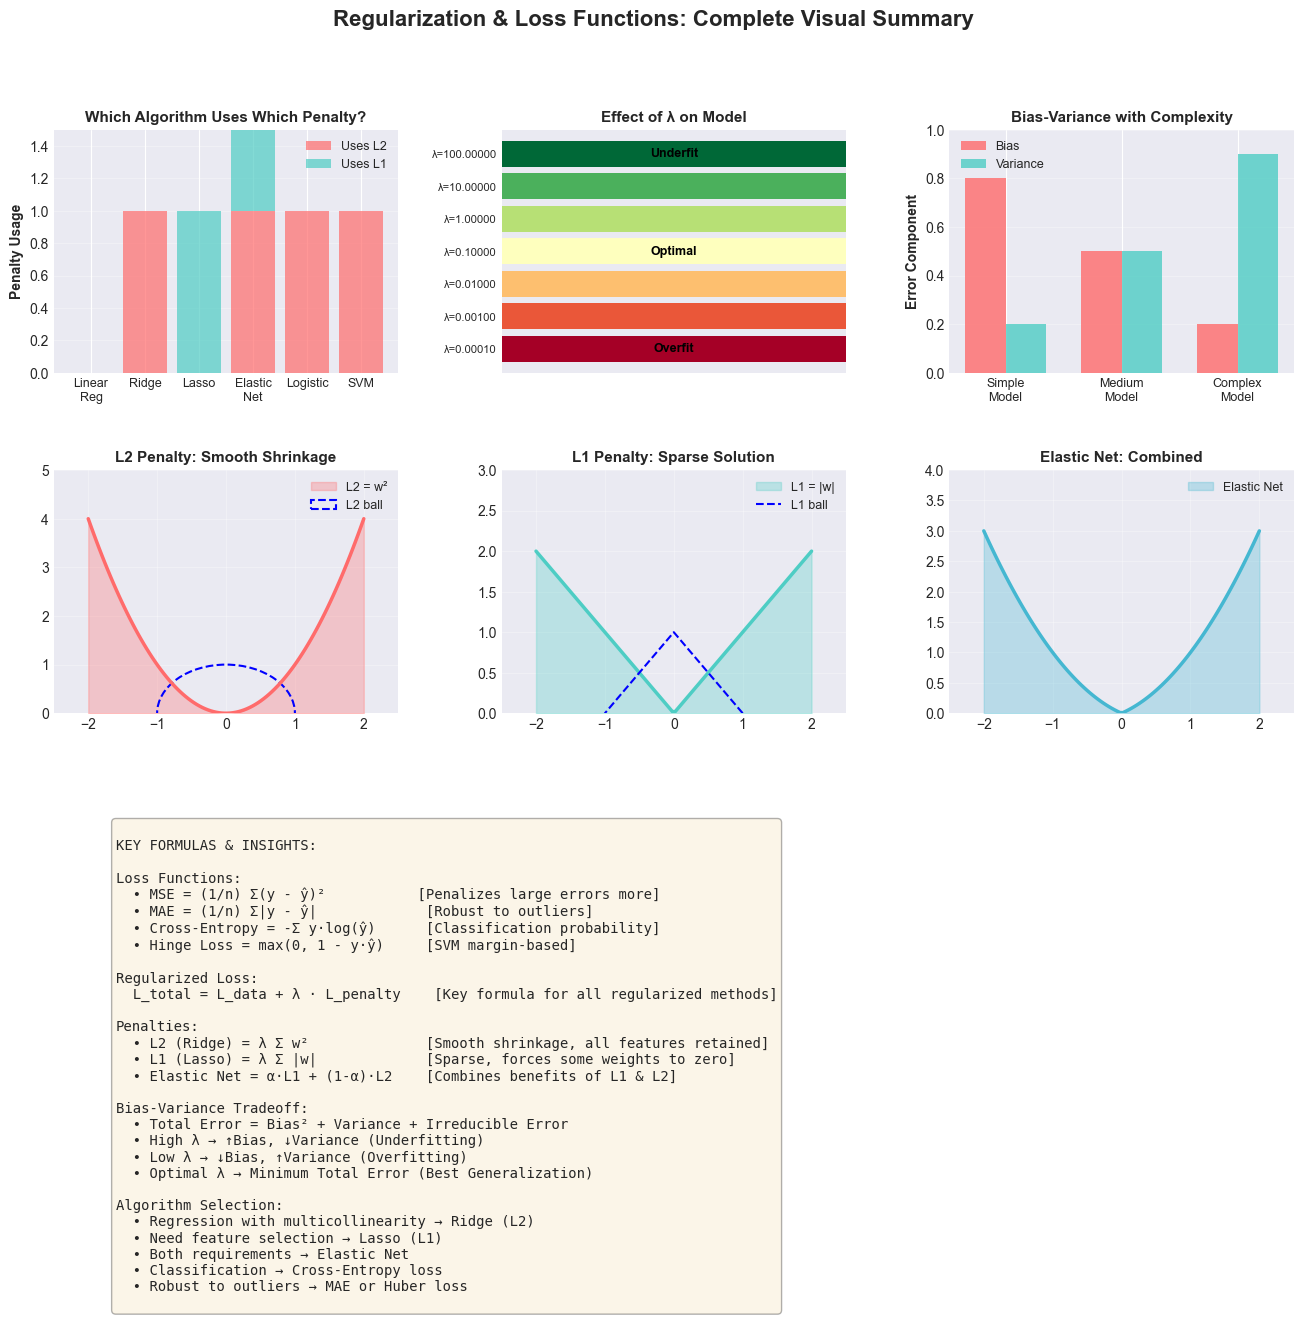

✅ Complete visual summary created

📊 All concepts visualized and explained!


In [17]:
# Create a visual summary infographic
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('Regularization & Loss Functions: Complete Visual Summary', 
            fontsize=16, fontweight='bold', y=0.98)

# 1. Loss Functions Comparison (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
algorithms = ['Linear\nReg', 'Ridge', 'Lasso', 'Elastic\nNet', 'Logistic', 'SVM']
uses_l1 = [0, 0, 1, 1, 0, 0]
uses_l2 = [0, 1, 0, 1, 1, 1]
colors_algo = ['#FF6B6B', '#FF6B6B', '#4ECDC4', '#45B7D1', '#A29BFE', '#F7B731']

x_pos = np.arange(len(algorithms))
ax1.bar(x_pos, uses_l2, label='Uses L2', color='#FF6B6B', alpha=0.7)
ax1.bar(x_pos, uses_l1, label='Uses L1', color='#4ECDC4', alpha=0.7, bottom=uses_l2)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(algorithms, fontsize=9)
ax1.set_ylabel('Penalty Usage', fontsize=10, fontweight='bold')
ax1.set_title('Which Algorithm Uses Which Penalty?', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.5)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Lambda Effect (Top Center)
ax2 = fig.add_subplot(gs[0, 1])
lambdas_quick = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
effect_names = ['Overfit', '', '', 'Optimal', '', '', 'Underfit']
colors_effect = plt.cm.RdYlGn(np.linspace(0, 1, len(lambdas_quick)))

bars = ax2.barh(range(len(lambdas_quick)), [1]*len(lambdas_quick), color=colors_effect)
ax2.set_yticks(range(len(lambdas_quick)))
ax2.set_yticklabels([f'λ={l:.5f}' for l in lambdas_quick], fontsize=8)
ax2.set_xlim(0, 1)
ax2.set_xticks([])
ax2.set_title('Effect of λ on Model', fontsize=11, fontweight='bold')

for i, name in enumerate(effect_names):
    if name:
        ax2.text(0.5, i, name, ha='center', va='center', fontweight='bold', fontsize=9, color='black')

# 3. Model Complexity (Top Right)
ax3 = fig.add_subplot(gs[0, 2])
complexity = ['Simple\nModel', 'Medium\nModel', 'Complex\nModel']
bias = [0.8, 0.5, 0.2]
variance = [0.2, 0.5, 0.9]
x_pos_complex = np.arange(len(complexity))
width = 0.35

ax3.bar(x_pos_complex - width/2, bias, width, label='Bias', color='#FF6B6B', alpha=0.8)
ax3.bar(x_pos_complex + width/2, variance, width, label='Variance', color='#4ECDC4', alpha=0.8)

ax3.set_xticks(x_pos_complex)
ax3.set_xticklabels(complexity, fontsize=9)
ax3.set_ylabel('Error Component', fontsize=10, fontweight='bold')
ax3.set_title('Bias-Variance with Complexity', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3, axis='y')

# 4. L2 Penalty Shape (Middle Left)
ax4 = fig.add_subplot(gs[1, 0])
w = np.linspace(-2, 2, 100)
ax4.fill_between(w, 0, w**2, color='#FF6B6B', alpha=0.3, label='L2 = w²')
ax4.plot(w, w**2, color='#FF6B6B', linewidth=2.5)
circle = plt.Circle((0, 0), 1, fill=False, edgecolor='blue', linestyle='--', linewidth=1.5, label='L2 ball')
ax4.add_patch(circle)
ax4.set_xlim(-2.5, 2.5)
ax4.set_ylim(0, 5)
ax4.set_title('L2 Penalty: Smooth Shrinkage', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)

# 5. L1 Penalty Shape (Middle Center)
ax5 = fig.add_subplot(gs[1, 1])
ax5.fill_between(w, 0, np.abs(w), color='#4ECDC4', alpha=0.3, label='L1 = |w|')
ax5.plot(w, np.abs(w), color='#4ECDC4', linewidth=2.5)
diamond_x = [1, 0, -1, 0, 1]
diamond_y = [0, 1, 0, -1, 0]
ax5.plot(diamond_x, diamond_y, 'b--', linewidth=1.5, label='L1 ball')
ax5.set_xlim(-2.5, 2.5)
ax5.set_ylim(0, 3)
ax5.set_title('L1 Penalty: Sparse Solution', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=9)

# 6. Elastic Net Shape (Middle Right)
ax6 = fig.add_subplot(gs[1, 2])
elastic = 0.5 * np.abs(w) + 0.5 * w**2
ax6.fill_between(w, 0, elastic, color='#45B7D1', alpha=0.3, label='Elastic Net')
ax6.plot(w, elastic, color='#45B7D1', linewidth=2.5)
ax6.set_xlim(-2.5, 2.5)
ax6.set_ylim(0, 4)
ax6.set_title('Elastic Net: Combined', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=9)

# 7. Loss Function Table Info (Bottom Left)
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

info_text = """
KEY FORMULAS & INSIGHTS:

Loss Functions:
  • MSE = (1/n) Σ(y - ŷ)²           [Penalizes large errors more]
  • MAE = (1/n) Σ|y - ŷ|             [Robust to outliers]
  • Cross-Entropy = -Σ y·log(ŷ)      [Classification probability]
  • Hinge Loss = max(0, 1 - y·ŷ)     [SVM margin-based]

Regularized Loss:
  L_total = L_data + λ · L_penalty    [Key formula for all regularized methods]

Penalties:
  • L2 (Ridge) = λ Σ w²              [Smooth shrinkage, all features retained]
  • L1 (Lasso) = λ Σ |w|             [Sparse, forces some weights to zero]
  • Elastic Net = α·L1 + (1-α)·L2    [Combines benefits of L1 & L2]

Bias-Variance Tradeoff:
  • Total Error = Bias² + Variance + Irreducible Error
  • High λ → ↑Bias, ↓Variance (Underfitting)
  • Low λ → ↓Bias, ↑Variance (Overfitting)
  • Optimal λ → Minimum Total Error (Best Generalization)

Algorithm Selection:
  • Regression with multicollinearity → Ridge (L2)
  • Need feature selection → Lasso (L1)
  • Both requirements → Elastic Net
  • Classification → Cross-Entropy loss
  • Robust to outliers → MAE or Huber loss
"""

ax7.text(0.05, 0.95, info_text, transform=ax7.transAxes, fontsize=10, 
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()

print("✅ Complete visual summary created")
print("\n📊 All concepts visualized and explained!")

## Summary: Everything You Need to Know

### 🎯 Core Concepts:

**1. Loss Functions** measure prediction error
- Different algorithms use different loss functions
- Goal: Minimize loss during training
- Must generalize to test data

**2. Regularization** prevents overfitting
- Adds penalty for model complexity
- Controls bias-variance tradeoff
- λ is the strength hyperparameter

**3. Three Types of Penalties:**
- **L2 (Ridge)**: Smooth, keeps all features
- **L1 (Lasso)**: Creates sparse solutions, feature selection
- **Elastic Net**: Combines both

**4. Bias-Variance Tradeoff:**
- Bias: Error from oversimplification
- Variance: Error from overfitting
- Goal: Minimize total error (Bias² + Variance)
- Regularization trades bias for variance

**5. Choosing λ (Regularization Strength):**
- Too small: Overfitting (high test error)
- Too large: Underfitting (high training error)
- Optimal: Found via cross-validation
- Use cross-validation curves to find it

### 📊 When to Use What:

| Problem | Solution |
|---------|----------|
| Multicollinearity | Ridge Regression |
| Need feature selection | Lasso Regression |
| Both above | Elastic Net |
| Need robustness | Robust loss (MAE, Huber) |
| Outliers important? | Use MAE, not MSE |
| Classification | Cross-Entropy + L1/L2 |
| Non-linear? | Neural Network + Regularization |

### ✨ Key Takeaways:

1. **Regularization is essential** for avoiding overfitting
2. **L1 vs L2 tradeoff** depends on your data structure
3. **λ must be tuned** using cross-validation
4. **Bias-Variance understanding** is crucial for ML success
5. **Different models use different losses** - always know your model's loss function
6. **Visualizations help understanding** - use them to debug your model